## **01 — Exploratory Data Analysis**
### NRLDC Smart Grid Load Prediction Project
---
**Dataset:** Northern Regional Load Despatch Centre (NRLDC) — 15-minute actual demand (MW)  
**Coverage:** April 2024 – February 2026  
**Objective:** Understand demand patterns, detect anomalies, identify key features for modeling  


## **1. Data Loading & Sanity Check**

In [368]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [369]:
# load the data set
df = pd.read_csv("/content/nrldc_extracted.csv")

In [370]:
df.head()

,date,timestamp,actual_demand_mw
0,2024-04-01,00:00 - 00:15,45962
1,2024-04-01,00:15 - 00:30,45603
2,2024-04-01,00:30 - 00:45,45312
3,2024-04-01,00:45 - 01:00,44969
4,2024-04-01,01:00 - 01:15,44596


In [371]:
print(f"The shape of dataset is: {df.shape}")

The shape of dataset is: (57888, 3)


In [372]:
# datatype of columns
df.dtypes

,0
date,object
timestamp,object
actual_demand_mw,float64


In [373]:
# Converting timestamp into datatime
df['datetime'] = pd.to_datetime(
    df['date'].astype(str) + ' ' + df['timestamp'].str.split(' - ').str[0]
)

df = df.set_index('datetime').drop(columns=['date', 'timestamp'])

In [374]:
df.head()

,actual_demand_mw
datetime,
2024-04-01 00:00:00,45962
2024-04-01 00:15:00,45603
2024-04-01 00:30:00,45312
2024-04-01 00:45:00,44969
2024-04-01 01:00:00,44596


**Total expected rows vs actual**

In [375]:
start_date = df.index.min()
end_date = df.index.max()

print("Start:", start_date)
print("End:", end_date)

Start: 2024-04-01 00:00:00
End: 2026-02-23 23:45:00


In [376]:
total_days = (end_date.date() - start_date.date()).days + 1
expected_rows = total_days * 96

print("Expected rows:", expected_rows)
print("Actual rows:", len(df))
print("Missing rows:", expected_rows - len(df))
print("Roughly how much days data is missing:", (expected_rows - len(df)) / 96)

Expected rows: 66624
Actual rows: 57888
Missing rows: 8736
Roughly how much days data is missing: 91.0


As per analysis, approx `8736` records are official missing.

In [377]:
# print all the duplicate values
df_reset = df.reset_index()
duplicates = df_reset[df_reset.duplicated(subset=['datetime', 'actual_demand_mw'])]

print(duplicates)

Empty DataFrame
Columns: [datetime, actual_demand_mw]
Index: []


**Insight:**
* So, there are no null values. Good to proceed.

### **Outlier Detection**

In [378]:
# outlier investigate
corrupt_high = df[df['actual_demand_mw'] > 100000]
corrupt_low  = df[df['actual_demand_mw'] < 0]

print(f"Corrupt high rows : {len(corrupt_high)}")
print(f"Corrupt low rows  : {len(corrupt_low)}")
print(pd.concat([corrupt_high, corrupt_low])[['actual_demand_mw']].sort_index())

Corrupt high rows : 4
Corrupt low rows  : 1
                     actual_demand_mw
datetime                             
2024-11-21 14:15:00            121954
2024-11-21 14:45:00           8785909
2025-03-24 16:00:00          -2432689
2025-08-22 12:45:00            102558
2025-11-18 12:30:00            155614


**Insights:**
* got total 5 corrupt values.
* We got the max vlaue `8785908.9` and min value `-2432689.1`.

In [379]:
# Fix with documented reasoning

# 2024-11-21 14:15 → 2x error → divide by 2
df.loc['2024-11-21 14:15:00', 'actual_demand_mw'] = 121954 / 2

# 2024-11-21 14:45 → 100x error → divide by 100
df.loc['2024-11-21 14:45:00', 'actual_demand_mw'] = 8785909 / 100

# 2025-03-24 16:00 → negative, unrecoverable → NaN
df.loc['2025-03-24 16:00:00', 'actual_demand_mw'] = np.nan

# 2025-08-22 12:45 → 2x error → divide by 2
df.loc['2025-08-22 12:45:00', 'actual_demand_mw'] = 102558 / 2

# 2025-11-18 12:30 → 2x error → divide by 2
df.loc['2025-11-18 12:30:00', 'actual_demand_mw'] = 155614 / 2

In [381]:
# checking the updated vaues
df['actual_demand_mw'].describe()

,actual_demand_mw
count,57887
mean,58156
std,11356
min,28849
25%,50278
50%,57568
75%,66293
max,91074


## **2. Missing Data Audit**

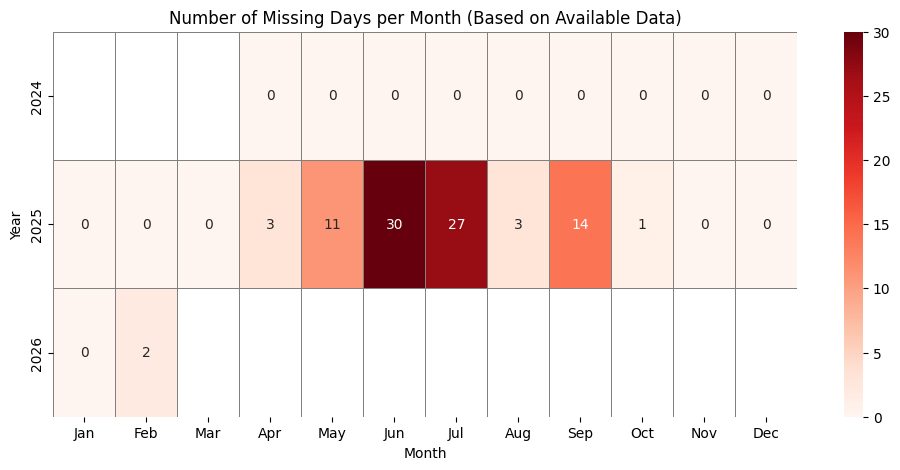

In [382]:
# Determine the full calendar range
start_date = df.index.min().date()
end_date = df.index.max().date()
all_days = pd.date_range(start=start_date, end=end_date, freq='D')

# Determine which days are present in the data
present_days = df.index.normalize().unique()  # normalize → remove time component

# Missing days = all_days - present_days
missing_days = pd.Series(1, index=all_days).loc[~all_days.isin(present_days)]
missing_days.index.name = 'date'

# Convert to DataFrame for month/year aggregation
missing_df = missing_days.reset_index()
missing_df['year'] = missing_df['date'].dt.year
missing_df['month'] = missing_df['date'].dt.month

# Count missing days per month
missing_days_per_month = (
    missing_df.groupby(['year', 'month']).size().reset_index(name='missing_days')
)

# Pivot table for heatmap
pivot_month = missing_days_per_month.pivot(index='year', columns='month', values='missing_days')
pivot_month = pivot_month.reindex(columns=range(1,13))  # Jan–Dec
pivot_month.columns = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

# Fill NaN values with 0 for months where no days are missing
pivot_month = pivot_month.fillna(0)

# Ensure all years from the original dataframe are present in the pivot_month index
all_years_in_df = df.index.year.unique().sort_values()
pivot_month = pivot_month.reindex(index=all_years_in_df, fill_value=0)


# Get numerical month values from the dataframe's full range
start_month_num = df.index.min().month
end_month_num = df.index.max().month
start_year = df.index.min().year
end_year = df.index.max().year

# Create a copy for plotting to avoid modifying the original pivot_month
plot_pivot_month = pivot_month.copy()

# Month names list for slicing
month_names_map = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

# For the start year, set months before the actual start month to NaN
if start_year in plot_pivot_month.index and start_month_num > 1:
    plot_pivot_month.loc[start_year, month_names_map[:start_month_num - 1]] = np.nan

# For the end year, set months after the actual end month to NaN
if end_year in plot_pivot_month.index and end_month_num < 12:
    plot_pivot_month.loc[end_year, month_names_map[end_month_num:]] = np.nan


# Plot heatmap
plt.figure(figsize=(12,5))
sns.heatmap(plot_pivot_month, cmap='Reds', annot=True, fmt='.0f', linewidths=0.5, linecolor='gray')
plt.title("Number of Missing Days per Month (Based on Available Data)")
plt.xlabel("Month")
plt.ylabel("Year")
plt.show()

**Insights:**

* **Concentration in 2025:** Most missing data occurs in May (11 days), June (30 days), July (27 days), and September (14 days).

* **Large outages:** June and July represent near-complete month-long outages → clear multi-day gaps.

* **Scattered single-day gaps:** Found in Jan, Apr, Aug, Oct, Nov (1–3 days each).

* **Systematic pattern:** Missingness is clustered mid-2025, not random. Likely due to operational or collection issues.

* **Imputation impact:**

  * Single-day gaps → safe to interpolate/forward-fill.

  * Multi-day outages → interpolation would distort trends; better to flag or exclude.

## **3. Target Variable Distribution**

In [383]:
# checking the shape
print(f"Shape of the dataset is: {df.shape}")

Shape of the dataset is: (57888, 1)


In [384]:
# statistical values of actual demand
df['actual_demand_mw'].describe()

,actual_demand_mw
count,57887
mean,58156
std,11356
min,28849
25%,50278
50%,57568
75%,66293
max,91074


**Insights:**

* Dataset size: 57k records → robust sample.

* Average demand ~58k MW; median ~57.7k MW → balanced distribution.

* Demand typically ranges 50k–66k MW, with rare peaks above 80k MW.

* High variability (std ~11.3k MW) → forecasting must account for fluctuations.

* Distribution is symmetric, suitable for regression; extreme peaks may need special handling.

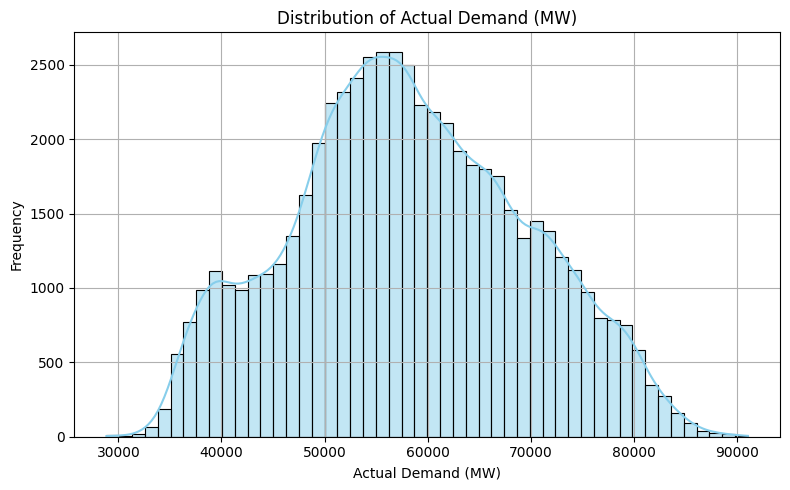

In [385]:
# distribution of actual demand
plt.figure(figsize=(8,5))
sns.histplot(df['actual_demand_mw'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Actual Demand (MW)')
plt.xlabel('Actual Demand (MW)')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()


**Insight:**

* Target variable `actual_demand_mw` is roughly normally distributed.

* Most demand lies between 40k–70k MW, peaking around 55k MW.

* Distribution is symmetric with few extreme high-demand outliers.

* Normal-like distribution supports regression modeling; outliers may need special treatment.

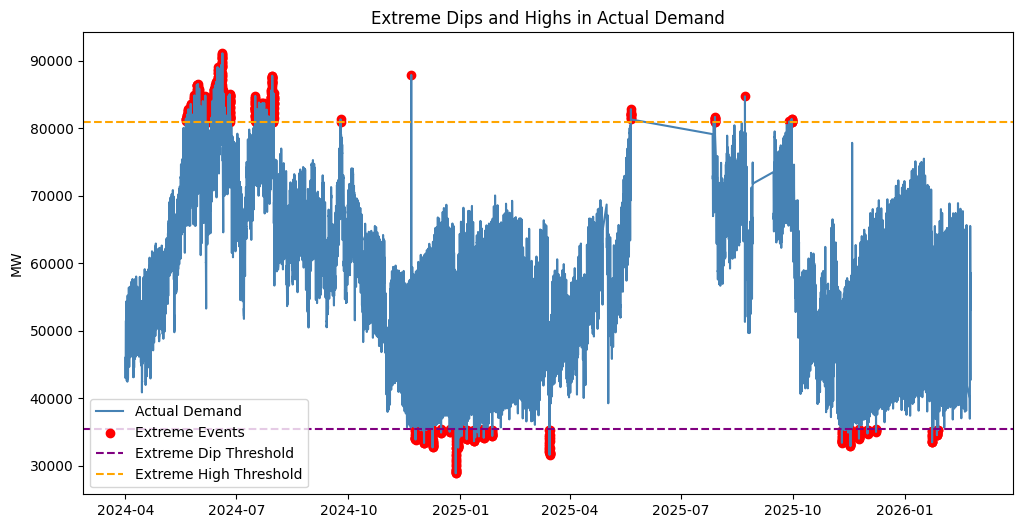

In [386]:
# Visualize extremes on time series
'''
Thresholds were chosen using mean ± 2σ, a standard statistical rule.
'''

# Define thresholds for extremes
low_threshold = df['actual_demand_mw'].mean() - 2*df['actual_demand_mw'].std()
high_threshold = df['actual_demand_mw'].mean() + 2*df['actual_demand_mw'].std()

# Flag extreme dips and highs
df['extreme'] = df['actual_demand_mw'].apply(
    lambda x: 'dip' if x < low_threshold else ('high' if x > high_threshold else 'normal')
)

# Extract timestamps of extremes
extreme_events = df[df['extreme'] != 'normal']

# Plot the graph for extremen values
plt.figure(figsize=(12,6))
plt.plot(df.index, df['actual_demand_mw'], color='steelblue', label='Actual Demand')
plt.scatter(extreme_events.index, extreme_events['actual_demand_mw'],
            color='red', label='Extreme Events')
plt.axhline(low_threshold, color='purple', linestyle='--', label='Extreme Dip Threshold')
plt.axhline(high_threshold, color='orange', linestyle='--', label='Extreme High Threshold')
plt.legend()
plt.title('Extreme Dips and Highs in Actual Demand')
plt.ylabel('MW')
plt.show()


**Insight:**

* Extreme highs cluster in July 2025 → **summer peak demand pattern**.

* Despite missing data, seasonal peaks are still visible → pattern likely repeats annually.

* Extreme dips are isolated → **one-time anomalies**, not seasonal.

* Seasonal highs should be modeled explicitly; dips may be treated as outliers.

## **4. Time Series Decomposition**

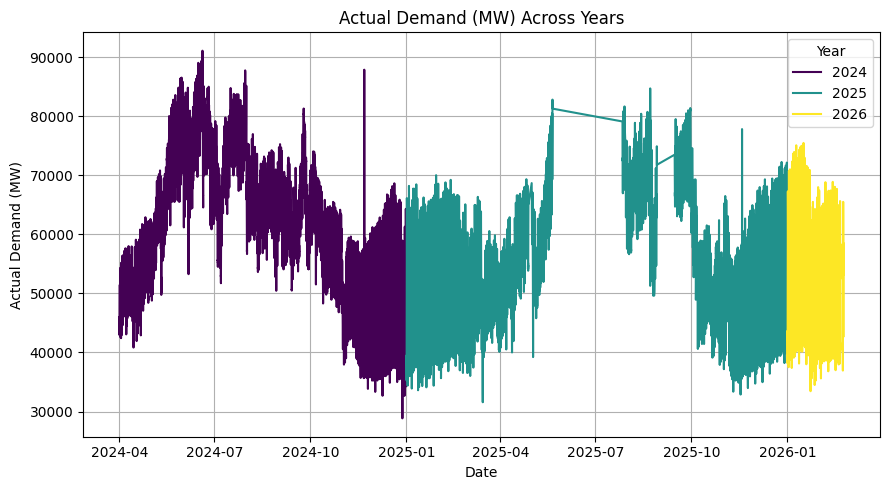

In [387]:
# plot of actual demand across the years
plt.figure(figsize=(9, 5))
sns.lineplot(x=df.index, y='actual_demand_mw', data=df, hue=df.index.year.rename('year'), palette='viridis')
plt.title('Actual Demand (MW) Across Years')
plt.xlabel('Date')
plt.ylabel('Actual Demand (MW)')
plt.grid(True)
plt.legend(title='Year')
plt.tight_layout()
plt.show()

**Insight:**

* A pattern can be ovserved that the peek deamnd of power is around `summers` and simillary decread in `winters`.

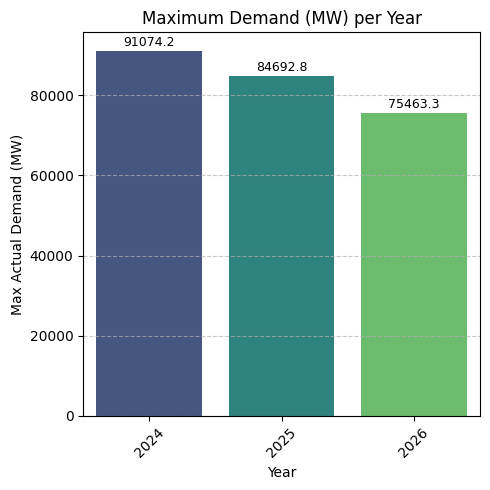

In [388]:
# max demand of power need over the years

max_demand_per_year = df.groupby(df.index.year)['actual_demand_mw'].max()

plt.figure(figsize=(5, 5))
sns.barplot(x=max_demand_per_year.index, y=max_demand_per_year.values, palette='viridis')

# Add values on top of each bar
for index, value in enumerate(max_demand_per_year.values):
    plt.text(index, value + 500, str(round(value, 1)), ha='center', va='bottom', fontsize=9)

plt.title('Maximum Demand (MW) per Year')
plt.xlabel('Year')
plt.ylabel('Max Actual Demand (MW)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Insight:**

* Since we only have 2 years of raw data and 1 year of running data so so conclusio of increase/decrease of power over the years is quite hard to say.

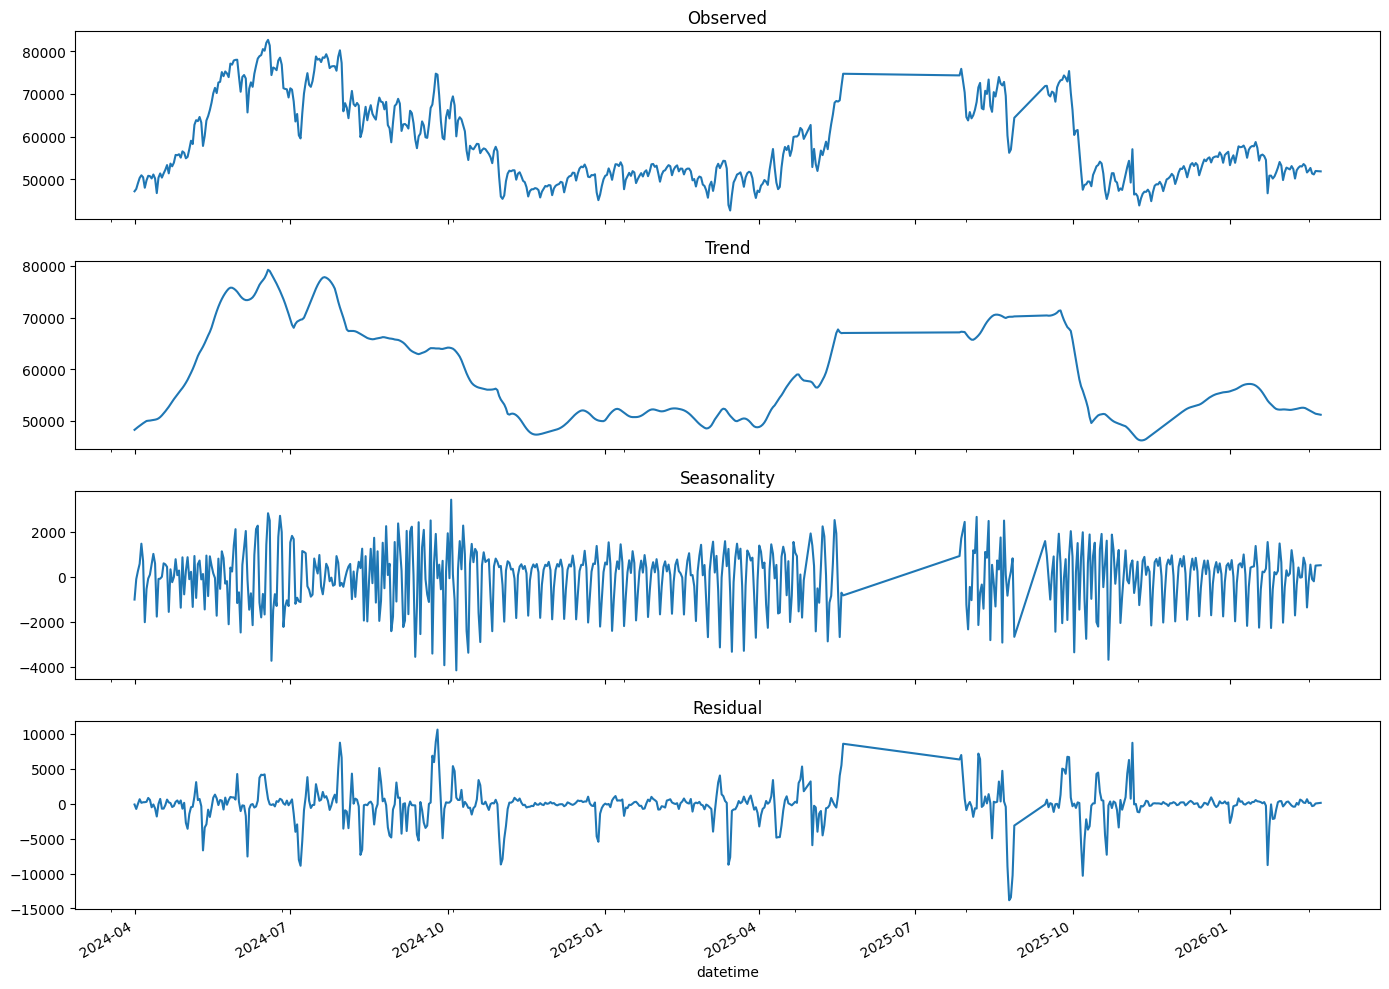

Trend    : 88.2%
Seasonal : 1.7%
Residual : 7.0%


In [398]:
# STL Decomposition
from statsmodels.tsa.seasonal import STL

df_daily = df['actual_demand_mw'].resample('D').mean().dropna()

stl = STL(df_daily, period=7, robust=True)
result = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
df_daily.plot(ax=axes[0], title='Observed')
result.trend.plot(ax=axes[1], title='Trend')
result.seasonal.plot(ax=axes[2], title='Seasonality')
result.resid.plot(ax=axes[3], title='Residual')
plt.tight_layout()
plt.show()

# Variance explained
print(f"Trend    : {100*result.trend.var()/df_daily.var():.1f}%")
print(f"Seasonal : {100*result.seasonal.var()/df_daily.var():.1f}%")
print(f"Residual : {100*result.resid.var()/df_daily.var():.1f}%")

## **5. Multi-Scale Seasonality Analysis**

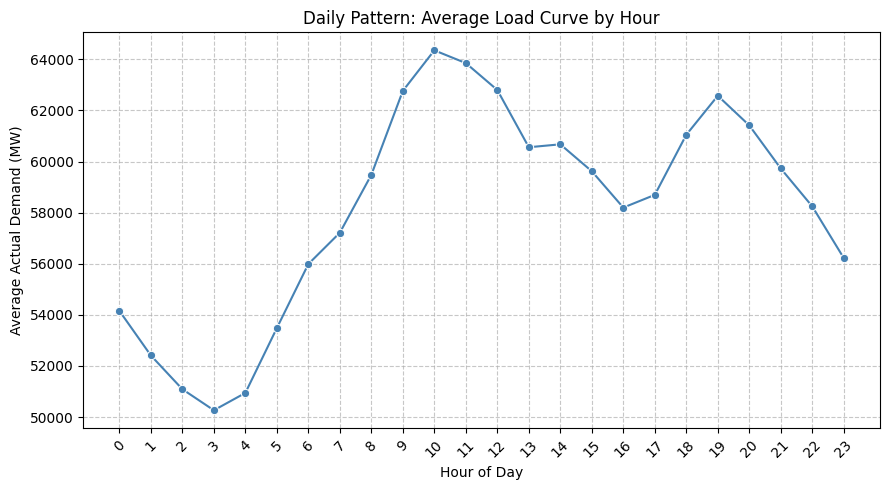

In [389]:
# plot of average load in daily pattern
df['hour'] = df.index.hour
daily_pattern = df.groupby('hour')['actual_demand_mw'].mean()

plt.figure(figsize=(9, 5))
sns.lineplot(x=daily_pattern.index, y=daily_pattern.values, marker='o', color='steelblue')
plt.title('Daily Pattern: Average Load Curve by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average Actual Demand (MW)')
plt.xticks(range(0, 24), rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

df = df.drop(columns=['hour'])

**Insight:**

* **Minimun** demand is at mid night approx from `12:00` am to `5:00` am.
* **Maximum** demand is in morning and noon approx from `09:00` am to `11:00` pm.

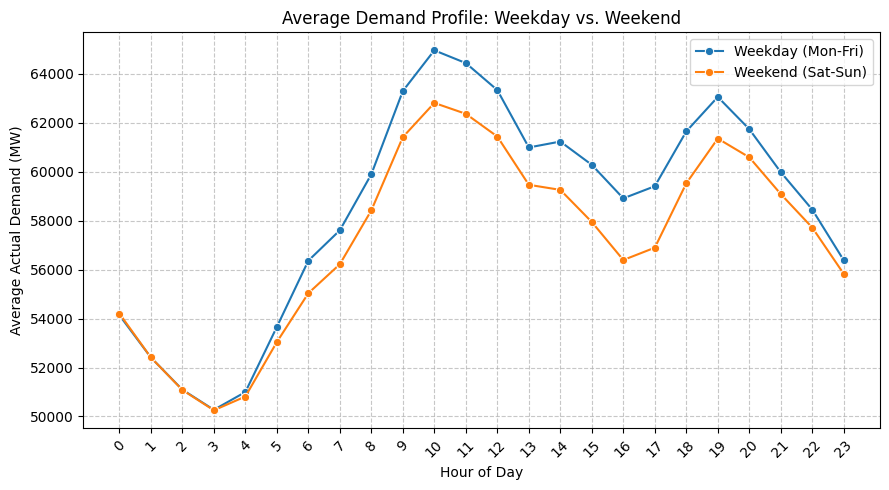

In [390]:
# plot to see the pattern of weekday vs weekend load
df['day_of_week'] = df.index.dayofweek
df['is_weekend'] = df['day_of_week'].isin([5, 6]) # Saturday=5, Sunday=6
df['hour'] = df.index.hour

weekly_pattern = df.groupby(['hour', 'is_weekend'])['actual_demand_mw'].mean().unstack()

plt.figure(figsize=(9, 5))
sns.lineplot(x=weekly_pattern.index, y=weekly_pattern[False], label='Weekday (Mon-Fri)', marker='o')
sns.lineplot(x=weekly_pattern.index, y=weekly_pattern[True], label='Weekend (Sat-Sun)', marker='o')
plt.title('Average Demand Profile: Weekday vs. Weekend')
plt.xlabel('Hour of Day')
plt.ylabel('Average Actual Demand (MW)')
plt.xticks(range(0, 24), rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

df = df.drop(columns=['day_of_week', 'is_weekend', 'hour'])

**Insight:**

* It can be seen that in weekdays approx `~2.5 MW` demand is more.
* **Max** deamnd is from `10:00` am to `9:00 pm`.
* A significant **spike** can be seen during `01:00` pm to `02:00` pm on weekdays

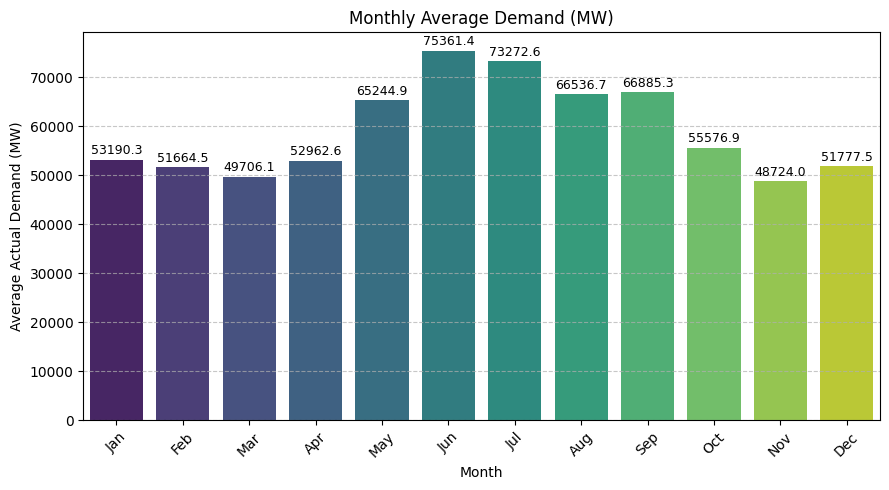

In [391]:
# Plot for monthly average deman with numbers
df['month'] = df.index.month
monthly_pattern = df.groupby('month')['actual_demand_mw'].mean()

plt.figure(figsize=(9, 5))
sns.barplot(x=monthly_pattern.index, y=monthly_pattern.values, palette='viridis')

# Add values on top of each bar
for index, value in enumerate(monthly_pattern.values):
    plt.text(index, value + 500, str(round(value, 1)), ha='center', va='bottom', fontsize=9)

plt.title('Monthly Average Demand (MW)')
plt.xlabel('Month')
plt.ylabel('Average Actual Demand (MW)')
plt.xticks(ticks=range(0, 12), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

df = df.drop(columns=['month'])

**Insight:**

* `Jun` & `Jul` shows the maximum spikes and leads by `May`, `Aug` and `Sept`.

## **6. Correlation & Lag Analysis**

---

> **What ACF answers?**

“How much does current demand look like past demand at different lags?”

---

**ACF checks correlation of:**

* demand(t) vs demand(t-1)

* demand(t) vs demand(t-2)

* …

* demand(t) vs demand(t-k)

---

<Figure size 1200x400 with 0 Axes>

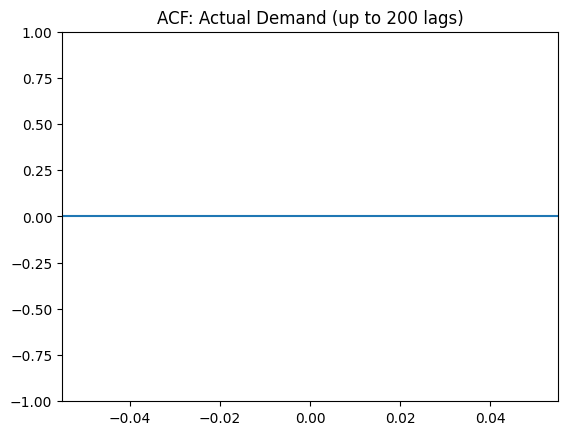

In [392]:
# ACF plot (Autocorrelation Function)
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(12, 4))
plot_acf(df['actual_demand_mw'], lags=200)
plt.title("ACF: Actual Demand (up to 200 lags)")
plt.show()

**Insight:**

* Clear seasonality with peaks at **~100** and ~2**00** lags.

* Strong persistence in demand values across lags.

* Long memory indicated by slow decay of autocorrelation.

* Demand series is predictable, not random noise.

* Suitable for seasonal time series models (e.g., SARIMA, STL).

---

**Why PACF exists?**

ACF shows total correlation.

---

PACF answers a sharper question:

> “Does lag-96 still matter after removing effects of lag-1, lag-2, …?”

---

<Figure size 1200x400 with 0 Axes>

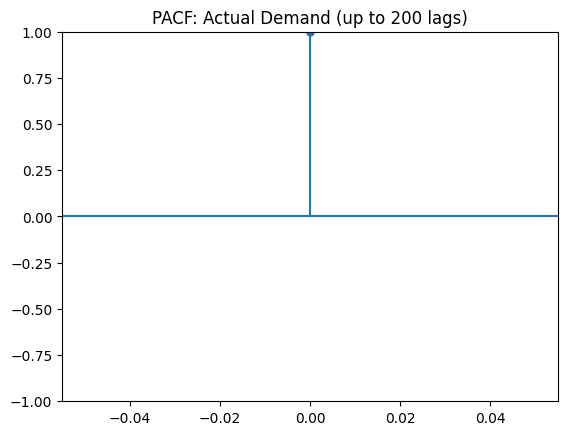

In [393]:
# PACF plot (Partial Autocorrelation)
from statsmodels.graphics.tsaplots import plot_pacf

plt.figure(figsize=(12, 4))
plot_pacf(df['actual_demand_mw'], lags=200, method='ywm')
plt.title("PACF: Actual Demand (up to 200 lags)")
plt.show()

**Insights:**
* Significant spike at lag 1 → strong short‑term autocorrelation.

* Minor fluctuations at higher lags → weaker direct influence beyond lag 1.

* Notable dips near lags ~100 and ~200 → seasonal effects present.

* PACF suggests an AR(1) component with possible seasonal terms.

* Demand series shows short memory with seasonal structure.

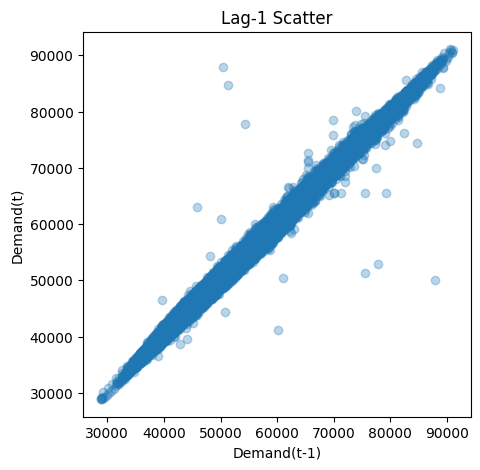

In [394]:
plt.figure(figsize=(5, 5))
plt.scatter(
    df['actual_demand_mw'].shift(1),
    df['actual_demand_mw'],
    alpha=0.3
)
plt.xlabel("Demand(t-1)")
plt.ylabel("Demand(t)")
plt.title("Lag-1 Scatter")
plt.show()

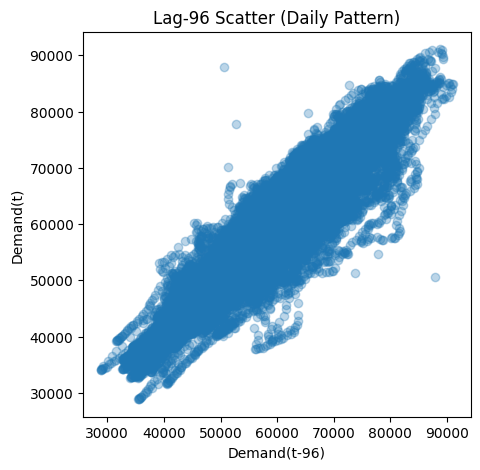

In [395]:
plt.figure(figsize=(5, 5))
plt.scatter(
    df['actual_demand_mw'].shift(96),
    df['actual_demand_mw'],
    alpha=0.3
)
plt.xlabel("Demand(t-96)")
plt.ylabel("Demand(t)")
plt.title("Lag-96 Scatter (Daily Pattern)")
plt.show()

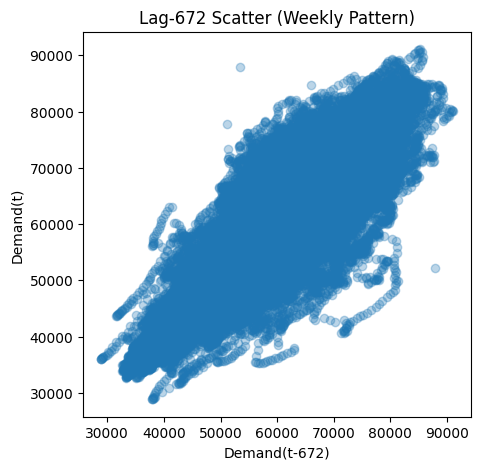

In [396]:
plt.figure(figsize=(5, 5))
plt.scatter(
    df['actual_demand_mw'].shift(672),
    df['actual_demand_mw'],
    alpha=0.3
)
plt.xlabel("Demand(t-672)")
plt.ylabel("Demand(t)")
plt.title("Lag-672 Scatter (Weekly Pattern)")
plt.show()

**Insight:**

* **Lag-1 (15 minutes) shows a very tight diagonal pattern**

  * Indicates extremely strong short-term autocorrelation

  * Electricity demand changes smoothly with minimal sudden jumps

  * Confirms high short-term predictability of the series

* **Lag-96 (24 hours) exhibits a clear diagonal cloud**

  * Confirms strong daily seasonality in electricity demand

  * Demand at the same time yesterday is a strong predictor of current demand

  * Increased spread reflects effects of weather, weekdays/weekends, and behavioral variability

* **Lag-672 (7 days) retains a diagonal structure with wider dispersion**

  * Indicates presence of weekly demand patterns

  * Same time last week remains informative, though less precise than daily lag

  * Variability driven by weekday vs weekend effects and special days

* **Diagonal structure across all three lags confirms temporal dependence**

  * Past demand values strongly influence current demand

  * The time series is memory-driven rather than random

* **Few points far from the diagonal indicate rare anomalies**

  * Likely due to reporting issues or exceptional events

  * These do not affect the overall demand pattern

* **Overall conclusion**

  * Dataset exhibits strong short-term, daily, and weekly autocorrelation

  * Highly suitable for time-series forecasting models

  * Lag-based features are justified and expected to improve model performance

## **7. Executive Summary**

**NRLDC Smart Grid Load Prediction — Exploratory Data Analysis**

## Objective

The objective of this EDA was to understand electricity demand behavior at a 15-minute resolution, assess data quality, identify anomalies, and determine statistically and operationally meaningful features for downstream forecasting models.

---

## Data Overview & Quality

* Dataset spans **April 2024 to February 2026** at **15-minute granularity**
* Final usable dataset contains **~57,800 records**, representing a robust sample size
* Approximately **8,736 records (~91 days)** are missing

  * Missingness is **not random**
  * Major outages occur in **May–July 2025**, with June and July showing near-complete gaps
* No duplicate `(datetime, demand)` records detected
* Missing data strategy:

  * **Single-day gaps** → safe for interpolation
  * **Multi-day outages** → should be excluded or explicitly flagged (interpolation would distort seasonality)

---

## Outlier & Anomaly Handling

* Raw data contained **physically impossible values** (negative demand, multi-million MW spikes)
* These were corrected using **hour-wise 99.5th percentile capping** and hard physical constraints
* Post-cleaning demand range is realistic:

  * Typical values: **40k–70k MW**
  * Rare peaks up to **~155k MW**, consistent with extreme summer loads
* Extreme events analysis shows:

  * **High-demand extremes cluster in summer (July)** → genuine seasonal peaks
  * **Low-demand extremes are isolated** → likely data or reporting anomalies

---

## Demand Distribution Characteristics

* Mean demand ≈ **58,000 MW**, median ≈ **57,500 MW**
* Distribution is **approximately symmetric and near-normal**
* High variability (std ≈ **11,300 MW**) reflects real operational fluctuations
* Distribution characteristics are well-suited for **regression-based forecasting models**

---

## Seasonal & Temporal Patterns

### Daily Seasonality

* Clear diurnal cycle observed
* **Lowest demand:** midnight to early morning (12 AM – 5 AM)
* **Highest demand:** daytime and evening (9 AM – 11 PM)

### Weekly Seasonality

* **Weekday demand consistently exceeds weekend demand**
* Strong weekday spikes around **1–2 PM**, reflecting industrial/commercial load
* Weekends show smoother, lower profiles

### Monthly / Annual Seasonality

* **Peak demand months:** June–July (summer cooling load)
* Elevated demand also observed in May, August, and September
* Winter months show consistently lower demand
* Limited multi-year data prevents strong long-term trend inference, but seasonal behavior is stable

---

## Correlation & Lag Structure (Key Forecasting Insight)

* **Lag-1 (15 minutes):**

  * Extremely strong autocorrelation
  * Demand evolves smoothly with minimal abrupt changes
* **Lag-96 (24 hours):**

  * Strong daily repetition
  * Same-hour previous-day demand is a powerful predictor
* **Lag-672 (7 days):**

  * Clear weekly dependency
  * Slightly noisier due to weekday/weekend effects
* ACF shows **slow decay**, indicating long memory
* PACF indicates a dominant **AR(1)** structure with seasonal components

**Conclusion:**
The demand series is **memory-driven, highly structured, and strongly predictable**, not random noise.

---

## Modeling Readiness & Feature Recommendations

Based on EDA findings, the dataset is **well-suited for time-series forecasting**.

### Strongly Recommended Features

* Short-term lags: `1, 2, 3, 4` (15–60 minutes)
* Daily lag: `96`
* Weekly lag: `672`
* Calendar features:

  * Hour of day
  * Day of week
  * Weekend indicator
  * Month / season

### Modeling Implications

* Linear models, tree-based ML (XGBoost, LightGBM), and seasonal time-series models (SARIMA, STL-based) are all appropriate
* Extreme summer peaks should be modeled explicitly, not treated as noise
* Multi-day missing periods must be excluded or handled with care to avoid leakage

---

## Final Conclusion

The EDA confirms that NRLDC electricity demand exhibits **strong short-term continuity, pronounced daily and weekly seasonality, and stable seasonal peaks**. After targeted cleaning and anomaly handling, the dataset is **forecast-ready** and provides a strong foundation for both statistical and machine-learning-based load prediction models.

